# 08. Inference Demo: Ring-Aware Topic Classification

**Цель:** показать как система присваивает тему новому документу с учётом зоны (кольца).

**Принцип:**
```
новый текст
    -> embed (USER-bge-m3)
    -> model.transform() -> topic_id + hdbscan_probability
    -> cosine_distance(doc_emb, topic_centroid) -> зона
    -> метка с глубиной по зоне: ядро=l1->l2->l3, основная=l1->l2, периферия=l1
```

**Зачем зона важна:**
- `hdbscan_probability` - уверенность кластеризатора, считается при обучении
- `cosine_distance` до центроида - геометрическая близость к "типичному" документу темы
- Вместе они дают честный `confidence`: периферийный документ получает более консервативную метку

Источники:
- Ring Sampling
- `model.transform()` API: Grootendorst (2022), BERTopic docs

In [1]:
import torch
import numpy as np
import pandas as pd

print(pd.__version__)
print(np.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

3.0.2
2.4.4
2.10.0+cu130
True
NVIDIA GeForce RTX 5060 Ti


In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42

MODELS_DIR = Path("models/topic_evolution")
RESULTS_DIR = Path("results/topic_labeling")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDER_NAME = "deepvk/USER-bge-m3"

# Границы колец из 07_topic_labeling.ipynb
# compute_adaptive_ring_boundaries вернул: q_low=0.234, q_high=0.305
# Грузим из summary чтобы не хардкодить
with open(RESULTS_DIR / "labeling_summary.json", encoding="utf-8") as f:
    labeling_summary = json.load(f)

ring_boundaries = labeling_summary["ring_params"]["boundaries"]
# [(0.0, q_low), (q_low, q_high), (q_high, 1.0)]
Q_LOW = ring_boundaries[0][1]  # граница ядро / основная
Q_HIGH = ring_boundaries[1][1]  # граница основная / периферия

RINGS = [
    (0.00, Q_LOW, "Ядро", "#2166ac"),
    (Q_LOW, Q_HIGH, "Основная", "#4dac26"),
    (Q_HIGH, 1.00, "Периферия", "#d01c8b"),
]

print("Границы колец:")
print(f"\tЯдро: [0.000, {Q_LOW:.3f})")
print(f"\tОсновная: [{Q_LOW:.3f}, {Q_HIGH:.3f})")
print(f"\tПериферия: [{Q_HIGH:.3f}, 1.000)")

Границы колец:
	Ядро: [0.000, 0.234)
	Основная: [0.234, 0.305)
	Периферия: [0.305, 1.000)


In [3]:
from pynndescent import NNDescent

_original_setstate = NNDescent.__setstate__


def _patched_setstate(self, d):
    defaults = {
        "quantization": None,
        "_min_distance": 0.0,
        "parallel_batch_queries": False,
    }
    for key, val in defaults.items():
        if key not in d:
            d[key] = val
    _original_setstate(self, d)


NNDescent.__setstate__ = _patched_setstate
print("pynndescent патч применён")

pynndescent патч применён


## 1. Загрузка модели, эмбеддера и меток

In [4]:
# Используем срез B (2024-H1) как более свежую модель
SLICE_NAME = "2024-H1"
model = BERTopic.load(str(MODELS_DIR / "bertopic_2024H1"))

# Таблица меток из 07_topic_labeling.ipynb
labels_df = pd.read_csv(RESULTS_DIR / "topic_labels.csv", encoding="utf-8")
labels_df["top_words"] = labels_df["top_words"].apply(json.loads)

# Только метки для нужного среза, индексируем по topic_id
slice_labels = (
    labels_df[labels_df["slice"] == SLICE_NAME]
    .set_index("topic_id")
    .to_dict(orient="index")
)

print(f"Модель: {SLICE_NAME}")
print(f"Тем в модели (без шума): {len([t for t in model.get_topics() if t != -1])}")
print(f"Меток загружено: {len(slice_labels)}")

# Эмбеддер - тот же что при обучении!
print(f"\nЗагружаем эмбеддер {EMBEDDER_NAME}...")
embedder = SentenceTransformer(EMBEDDER_NAME)
print("Эмбеддер готов")

Модель: 2024-H1
Тем в модели (без шума): 248
Меток загружено: 248

Загружаем эмбеддер deepvk/USER-bge-m3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Эмбеддер готов


## 2. Функция инференса

Два независимых сигнала уверенности:
- **hdbscan_probability** - насколько документ «принадлежит» кластеру по HDBSCAN
- **cosine_distance** до центроида -> зона -> глубина метки

Итоговый `confidence = hdbscan_prob * (1 - cosine_dist_normalized)` - интегральная оценка.

In [5]:
CONFIDENCE_THRESHOLD = 0.3
MIN_ALPHA_RATIO = 0.3
MIN_TEXT_LEN = 50


def get_zone(cosine_dist: float, rings: list = RINGS) -> tuple[str, str]:
    for i, (low, high, name, _) in enumerate(rings):
        if low <= cosine_dist < high:
            return f"ring_{i + 1}", name
    return "ring_3", "Периферия"


def get_label_by_zone(label_row: dict, ring_key: str) -> str:
    l1 = label_row.get("l1", "")
    l2 = label_row.get("l2", "")
    l3 = label_row.get("l3", "")
    is_heterogeneous = label_row.get("heterogeneous", False)
    periphery_topic = label_row.get("periphery_topic", "")
    if ring_key == "ring_1":
        return f"{l1} -> {l2} -> {l3}"
    elif ring_key == "ring_2":
        return f"{l1} -> {l2}"
    else:
        if is_heterogeneous and periphery_topic:
            return f"{l1} [периферия гетерогенного кластера]"
        return l1


def is_valid_input(text: str) -> bool:
    if len(text) < MIN_TEXT_LEN:
        return False
    alpha_ratio = sum(c.isalpha() for c in text) / len(text)
    return alpha_ratio >= MIN_ALPHA_RATIO


def soft_assign(doc_emb: np.ndarray, model: BERTopic) -> tuple[int, float]:
    topic_ids = sorted([t for t in model.get_topics().keys() if t != -1])
    centroids = np.array([model.topic_embeddings_[tid + 1] for tid in topic_ids])
    dists = cosine_distances(doc_emb, centroids)[0]
    best_idx = int(dists.argmin())
    return topic_ids[best_idx], float(1.0 - dists[best_idx])


def classify_document(
    text: str,
    model: BERTopic,
    embedder: SentenceTransformer,
    slice_labels: dict,
    rings: list = RINGS,
) -> dict:
    if not is_valid_input(text):
        return {
            "topic_id": -1,
            "hdbscan_prob": 0.0,
            "cosine_dist": None,
            "zone": "Шум",
            "ring_key": None,
            "label": "Неклассифицировано",
            "top_words": [],
            "core_topic": "",
            "periphery_topic": "",
            "heterogeneous": False,
            "confidence": 0.0,
            "assignment_method": "invalid",
        }

    doc_emb = embedder.encode(
        [text], normalize_embeddings=True, show_progress_bar=False
    )

    topics, probs = model.transform([text], embeddings=doc_emb)
    topic_id = int(topics[0])
    hdbscan_p = float(probs[0]) if probs is not None else 0.0

    assignment_method = "hdbscan"
    if topic_id == -1 or hdbscan_p < CONFIDENCE_THRESHOLD:
        topic_id, hdbscan_p = soft_assign(doc_emb, model)
        assignment_method = "soft_assign"

    topic_centroid = model.topic_embeddings_[topic_id + 1].reshape(1, -1)
    cosine_dist = float(cosine_distances(doc_emb, topic_centroid)[0, 0])

    ring_key, zone_name = get_zone(cosine_dist, rings)

    label_row = slice_labels.get(topic_id, {})
    label = get_label_by_zone(label_row, ring_key) if label_row else "Нет метки"

    confidence = round(hdbscan_p * (1.0 - min(cosine_dist, 1.0)), 3)

    return {
        "topic_id": topic_id,
        "hdbscan_prob": round(hdbscan_p, 3),
        "cosine_dist": round(cosine_dist, 3),
        "zone": zone_name,
        "ring_key": ring_key,
        "label": label,
        "top_words": label_row.get("top_words", [])[:6],
        "core_topic": label_row.get("core_topic", ""),
        "periphery_topic": label_row.get("periphery_topic", ""),
        "heterogeneous": label_row.get("heterogeneous", False),
        "confidence": confidence,
        "assignment_method": assignment_method,
    }


print("Функции инференса определены")

Функции инференса определены


## 3. Тест на примерах

Набор тестовых документов покрывает:
- явные случаи (должны попасть в ядро или основную)
- пограничные случаи (смешанная тема -> периферия)
- шумовые / нерелевантные тексты

Ожидаемое поведение: чем более "типичный" текст, тем конкретнее метка.

In [6]:
TEST_DOCS = [
    # --- ЯВНЫЕ ---
    {
        "text": "Сегодня в Москве ожидается снег, температура опустится до -15 градусов. "
        "Синоптики предупреждают о сильном ветре и метели.",
        "expected_l1": "Общество",
        "comment": "Явная погода",
    },
    {
        "text": "Президент провёл встречу с премьер-министром. "
        "По итогам переговоров подписан ряд двусторонних соглашений о сотрудничестве.",
        "expected_l1": "Политика",
        "comment": "Явная политика",
    },
    {
        "text": "В центре города вспыхнул пожар в жилом доме. "
        "Пожарные расчёты прибыли на место, эвакуированы 40 человек.",
        "expected_l1": "Происшествия",
        "comment": "Явные происшествия",
    },
    {
        "text": "Сборная России по хоккею победила в матче со счётом 3:1. "
        "Хет-трик оформил нападающий в третьем периоде.",
        "expected_l1": "Спорт",
        "comment": "Явный спорт",
    },
    {
        "text": "Бездомного пса подобрали волонтёры и доставили в приют. "
        "Животное нуждается в лечении и ищет хозяев.",
        "expected_l1": "Общество",
        "comment": "Животные (явное ядро темы)",
    },
    # --- ПОГРАНИЧНЫЕ ---
    {
        "text": "Экономика страны замедляется на фоне внешних рисков. "
        "Президент провёл совещание с министрами по вопросам бюджета.",
        "expected_l1": "Политика или Экономика",
        "comment": "Смешанная тема: экономика + политика",
    },
    {
        "text": "В зоопарке родился редкий детёныш амурского тигра. "
        "Одновременно в регионе обсуждают закон об эвтаназии бездомных животных.",
        "expected_l1": "Общество",
        "comment": "Животные - гетерогенный кластер (дикие + регулирование)",
    },
    {
        "text": "Матч прошёл в дождь, трибуны были заполнены наполовину. "
        "После игры тренер прокомментировал тактику команды на пресс-конференции.",
        "expected_l1": "Спорт",
        "comment": "Спорт - периферийный: акцент не на счёт, а на детали",
    },
    # --- ШУМОВЫЕ ---
    {
        "text": "Подписывайтесь на наш канал! Только у нас самые свежие новости 24/7.",
        "expected_l1": "Шум",
        "comment": "Реклама канала - ожидаем topic_id=-1 или низкий confidence",
    },
    {
        "text": "💥💥💥",
        "expected_l1": "Шум",
        "comment": "Только эмодзи - шум",
    },
]

print(f"Тестовых документов: {len(TEST_DOCS)}")

Тестовых документов: 10


In [7]:
results = []

for i, item in enumerate(TEST_DOCS):
    res = classify_document(
        text=item["text"],
        model=model,
        embedder=embedder,
        slice_labels=slice_labels,
    )
    res["text_short"] = item["text"][:80] + "..."
    res["comment"] = item["comment"]
    res["expected"] = item["expected_l1"]
    results.append(res)

    zone_emoji = {"Ядро": "🔵", "Основная": "🟢", "Периферия": "🟣", "Шум": "⚫"}
    e = zone_emoji.get(res["zone"], "❓")

    print(f"\n{'─' * 65}")
    print(f"[{i + 1}] {item['comment']}")
    print(f"  Текст:      {item['text'][:70]}...")
    print(f"  topic_id:   {res['topic_id']}  |  top_words: {res['top_words']}")
    print(f"  {e} Зона:      {res['zone']}  (cosine_dist={res['cosine_dist']})")
    print(f"  hdbscan_p:  {res['hdbscan_prob']}  |  confidence: {res['confidence']}")
    print(f"  Метка:      {res['label']}")
    if res["heterogeneous"]:
        print(f"  [!]  Гетерогенный кластер")
        print(f"  Периферия о: {res['periphery_topic'][:100]}")


─────────────────────────────────────────────────────────────────
[1] Явная погода
  Текст:      Сегодня в Москве ожидается снег, температура опустится до -15 градусов...
  topic_id:   45  |  top_words: ['градус', 'температура', 'погода', 'минус', 'синоптик', 'москва']
  🟢 Зона:      Основная  (cosine_dist=0.252)
  hdbscan_p:  0.457  |  confidence: 0.342
  Метка:      Общество -> Климат и окружающая среда

─────────────────────────────────────────────────────────────────
[2] Явная политика
  Текст:      Президент провёл встречу с премьер-министром. По итогам переговоров по...
  topic_id:   2  |  top_words: ['путин', 'владимир путин', 'владимир', 'кндр', 'президент', 'ким']
  🟣 Зона:      Периферия  (cosine_dist=0.309)
  hdbscan_p:  0.957  |  confidence: 0.661
  Метка:      Политика [периферия гетерогенного кластера]
  [!]  Гетерогенный кластер
  Периферия о: Прочие внешнеполитические и внутренние события с участием Владимира Путина, включая переговоры с Лук

──────────────────────────

## 4. Сводная таблица результатов

In [8]:
results_df = pd.DataFrame(results)[
    [
        "comment",
        "zone",
        "cosine_dist",
        "hdbscan_prob",
        "confidence",
        "label",
        "topic_id",
    ]
].rename(
    columns={
        "comment": "Документ",
        "zone": "Зона",
        "cosine_dist": "Cosine dist",
        "hdbscan_prob": "HDBSCAN prob",
        "confidence": "Confidence",
        "label": "Метка",
        "topic_id": "Topic ID",
    }
)

zone_colors = {
    "Ядро": "background-color: #d0e4f7",
    "Основная": "background-color: #d7f0d0",
    "Периферия": "background-color: #f5d0ea",
    "Шум": "background-color: #e0e0e0",
}


def color_zone(val):
    return zone_colors.get(val, "")


(
    results_df.style.map(color_zone, subset=["Зона"])
    .format({"Cosine dist": "{:.3f}", "HDBSCAN prob": "{:.3f}", "Confidence": "{:.3f}"})
    .set_caption("Ring-Aware классификация тестовых документов")
)

,Документ,Зона,Cosine dist,HDBSCAN prob,Confidence,Метка,Topic ID
0,Явная погода,Основная,0.252,0.457,0.342,Общество -> Климат и окружающая среда,45
1,Явная политика,Периферия,0.309,0.957,0.661,Политика [периферия гетерогенного кластера],2
2,Явные происшествия,Основная,0.286,1.000,0.714,Происшествия -> Чрезвычайные ситуации и ликвидация последствий,1
3,Явный спорт,Периферия,0.358,1.000,0.642,Спорт [периферия гетерогенного кластера],9
4,Животные (явное ядро темы),Основная,0.286,1.000,0.714,Общество -> Животные и обращение с ними,0
5,Смешанная тема: экономика + политика,Периферия,0.345,0.655,0.430,Политика,20
6,Животные - гетерогенный кластер (дикие + регулирование),Периферия,0.357,0.767,0.493,Общество [периферия гетерогенного кластера],0
7,"Спорт - периферийный: акцент не на счёт, а на детали",Периферия,0.326,0.674,0.454,Спорт [периферия гетерогенного кластера],9
8,Реклама канала - ожидаем topic_id=-1 или низкий confidence,Периферия,0.390,0.610,0.372,Политика [периферия гетерогенного кластера],185
9,Только эмодзи - шум,Шум,nan,0.000,0.000,Неклассифицировано,-1


## 5. Визуализация: cosine distance vs confidence по зонам

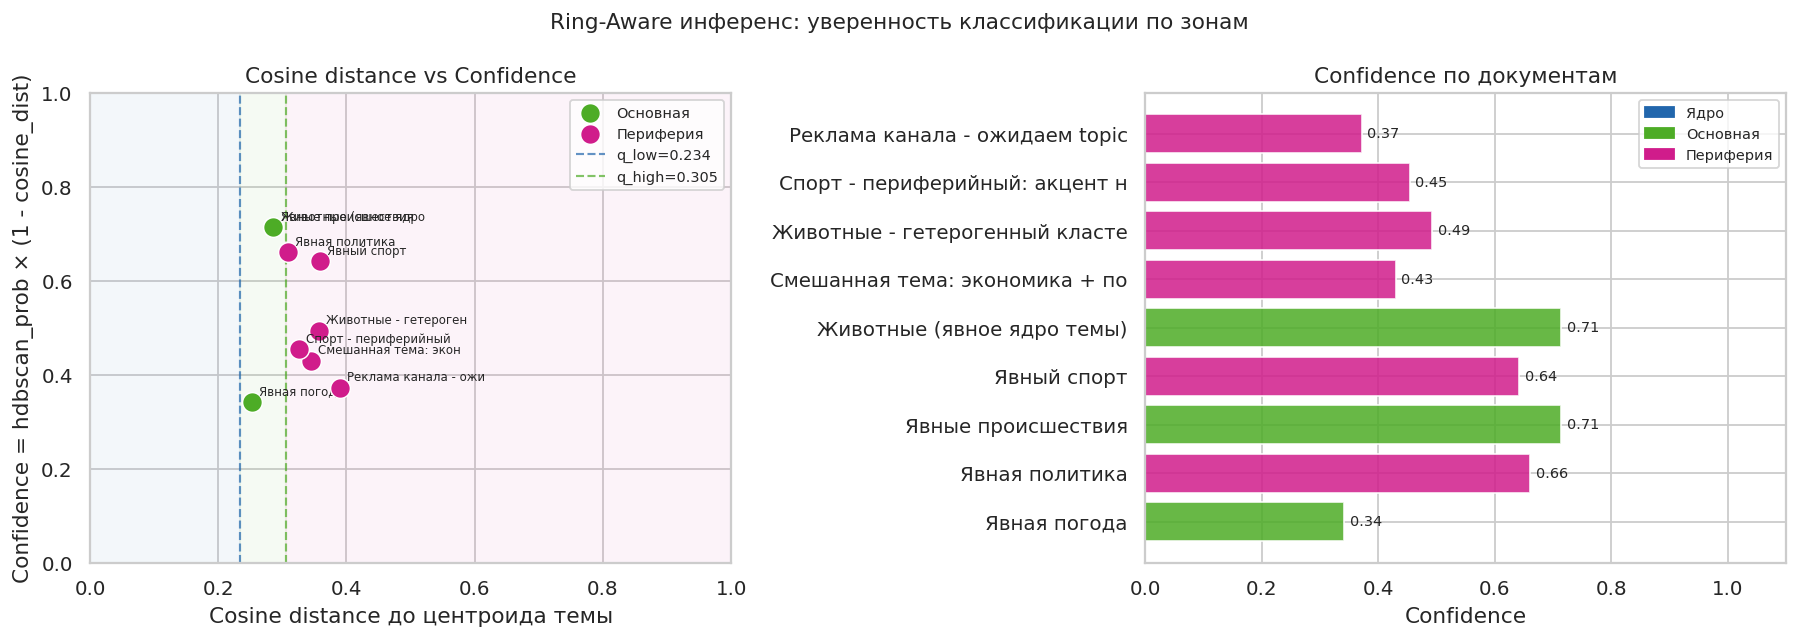

Сохранено: figures/14_[inference]_confidence_by_zone.png


In [9]:
# Фильтруем шум для визуализации
plot_df = pd.DataFrame(
    [r for r in results if r["zone"] != "Шум" and r["cosine_dist"] is not None]
)

if len(plot_df) == 0:
    print("Нет данных для визуализации (все документы - шум)")
else:
    ring_palette = {"Ядро": "#2166ac", "Основная": "#4dac26", "Периферия": "#d01c8b"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- График 1: scatter cosine_dist vs confidence ---
    ax = axes[0]
    for zone, grp in plot_df.groupby("zone"):
        ax.scatter(
            grp["cosine_dist"],
            grp["confidence"],
            color=ring_palette.get(zone, "gray"),
            label=zone,
            s=120,
            zorder=3,
            edgecolors="white",
            linewidths=0.8,
        )
        for _, row in grp.iterrows():
            ax.annotate(
                row["comment"][:20],
                (row["cosine_dist"], row["confidence"]),
                fontsize=6.5,
                xytext=(4, 4),
                textcoords="offset points",
            )

    # Вертикальные линии - границы колец
    ax.axvline(
        Q_LOW,
        color="#2166ac",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label=f"q_low={Q_LOW:.3f}",
    )
    ax.axvline(
        Q_HIGH,
        color="#4dac26",
        linestyle="--",
        linewidth=1.2,
        alpha=0.7,
        label=f"q_high={Q_HIGH:.3f}",
    )

    # Закраска зон
    ax.axvspan(0, Q_LOW, alpha=0.05, color="#2166ac")
    ax.axvspan(Q_LOW, Q_HIGH, alpha=0.05, color="#4dac26")
    ax.axvspan(Q_HIGH, 1.0, alpha=0.05, color="#d01c8b")

    ax.set_xlabel("Cosine distance до центроида темы")
    ax.set_ylabel("Confidence = hdbscan_prob × (1 - cosine_dist)")
    ax.set_title("Cosine distance vs Confidence")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # --- График 2: bar plot confidence по документам ---
    ax2 = axes[1]
    colors_bar = [ring_palette.get(z, "gray") for z in plot_df["zone"]]
    bars = ax2.barh(
        plot_df["comment"].str[:30],
        plot_df["confidence"],
        color=colors_bar,
        alpha=0.85,
        edgecolor="white",
    )
    ax2.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
    ax2.set_xlabel("Confidence")
    ax2.set_title("Confidence по документам")
    ax2.set_xlim(0, 1.1)

    patches = [mpatches.Patch(color=c, label=z) for z, c in ring_palette.items()]
    ax2.legend(handles=patches, fontsize=8)

    plt.suptitle("Ring-Aware инференс: уверенность классификации по зонам", fontsize=12)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "14_[inference]_confidence_by_zone.png", bbox_inches="tight"
    )
    plt.show()
    print("Сохранено: figures/14_[inference]_confidence_by_zone.png")

## 6. Анализ: как зона влияет на глубину метки

Проверяем ключевой тезис: периферийные документы -> более обобщённые метки.

In [10]:
# Считаем глубину метки по количеству уровней
def label_depth(label: str) -> int:
    if not label or label == "Неклассифицировано":
        return 0
    return label.count("->") + 1


for r in results:
    r["label_depth"] = label_depth(r["label"])

depth_by_zone = (
    pd.DataFrame(results)
    .groupby("zone")["label_depth"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Средняя глубина метки", "count": "Кол-во документов"})
)

print("Глубина метки по зонам:")
print(depth_by_zone.to_string())
print()
print("Интерпретация глубины:")
print("  1 уровень: только l1 (Политика)")
print("  2 уровня:  l1 -> l2 (Политика -> Международные отношения)")
print("  3 уровня:  l1 -> l2 -> l3 (полная метка)")

Глубина метки по зонам:
           Средняя глубина метки  Кол-во документов
zone                                               
Основная                     2.0                  3
Периферия                    1.0                  6
Шум                          0.0                  1

Интерпретация глубины:
  1 уровень: только l1 (Политика)
  2 уровня:  l1 -> l2 (Политика -> Международные отношения)
  3 уровня:  l1 -> l2 -> l3 (полная метка)


In [11]:
# Детальный вывод по каждому документу
print(f"{'Зона':<12} {'Depth':<6} {'Метка'}")
print("─" * 80)
zone_order = ["Ядро", "Основная", "Периферия", "Шум"]
for zone in zone_order:
    zone_results = [r for r in results if r["zone"] == zone]
    for r in zone_results:
        print(f"{r['zone']:<12} {r['label_depth']:<6} {r['label']}")
    if zone_results:
        print()

Зона         Depth  Метка
────────────────────────────────────────────────────────────────────────────────
Основная     2      Общество -> Климат и окружающая среда
Основная     2      Происшествия -> Чрезвычайные ситуации и ликвидация последствий
Основная     2      Общество -> Животные и обращение с ними

Периферия    1      Политика [периферия гетерогенного кластера]
Периферия    1      Спорт [периферия гетерогенного кластера]
Периферия    1      Политика
Периферия    1      Общество [периферия гетерогенного кластера]
Периферия    1      Спорт [периферия гетерогенного кластера]
Периферия    1      Политика [периферия гетерогенного кластера]

Шум          0      Неклассифицировано



## 7. Сохранение результатов

In [12]:
INFERENCE_DIR = Path("results/inference_demo")
INFERENCE_DIR.mkdir(parents=True, exist_ok=True)

# Убираем несериализуемые поля (top_words - уже список, ок)
save_results = [{k: v for k, v in r.items() if k != "text_short"} for r in results]
for r, item in zip(save_results, TEST_DOCS):
    r["text"] = item["text"]

with open(INFERENCE_DIR / "inference_demo_results.json", "w", encoding="utf-8") as f:
    json.dump(save_results, f, indent=2, ensure_ascii=False)

print(f"Результаты сохранены: {INFERENCE_DIR}/inference_demo_results.json")

print("\n=== Итого ===")
df_all = pd.DataFrame(results)
print(df_all.groupby("zone")[["confidence"]].agg(["mean", "count"]).round(3))
print(
    f"\nСреднее confidence (без шума): {df_all[df_all['zone'] != 'Шум']['confidence'].mean():.3f}"
)
print("\nСледующий шаг: 08_clearml_integration.ipynb")

Результаты сохранены: results\inference_demo/inference_demo_results.json

=== Итого ===
          confidence      
                mean count
zone                      
Основная       0.590     3
Периферия      0.509     6
Шум            0.000     1

Среднее confidence (без шума): 0.536

Следующий шаг: 08_clearml_integration.ipynb


## Итоги

### Что реализовано

1. **`classify_document()`** - полный инференс нового документа:
   - embed -> transform -> cosine distance -> зона -> метка с глубиной
   - два независимых сигнала уверенности: `hdbscan_prob` + `cosine_dist`
   - интегральный `confidence = hdbscan_prob × (1 - cosine_dist)`

2. **Ring-Aware метка** - глубина иерархии зависит от зоны:
   - Ядро -> полная метка `l1 -> l2 -> l3`
   - Основная -> `l1 -> l2`
   - Периферия -> только `l1` (или пометка о гетерогенности)

3. **Noise handling** - `topic_id == -1` возвращает `confidence=0.0`, `label="Неклассифицировано"`

4. **Гетерогенные кластеры** - явная пометка если периферия кластера про другое

### Связь с ML-сервисом

`classify_document()` - это прямой прототип обработчика RabbitMQ-сообщений в FastAPI-сервисе. В продакшне:
- `embedder` загружается один раз при старте сервиса
- `model` и `slice_labels` - из ClearML Model Registry
- `RINGS` - из `labeling_summary.json`, версионированного вместе с моделью